# Task 1: Natural Gas Price Analysis & Extrapolation

**Context**
- Trading desk wants to price commodity storage contracts (buy gas cheap, store it, sell later).
- Pricing needs a function that gives gas price for **any date**, past or future.
- We only have **month-end snapshots** (Oct 2020 - Sep 2024) -> need to interpolate + extrapolate 1 year.

**Task**
- Load monthly price data.
- Visualize to spot trend + seasonality (winter demand pushes price up).
- Fit a model that captures both trend and yearly seasonality.
- Wrap it in a function: `price(date) -> estimate`, working for any day (not just month-end) and up to 1 year beyond the data.

**Approach**
- Model: `price = trend(t) + seasonal(month) + noise`.
- Trend -> linear regression on time index `t`.
- Seasonality -> cyclical encoding `sin/cos(2*pi*month/12)` instead of 11 dummy variables (fewer params, smooth, naturally periodic).
- Fit via OLS (`statsmodels`) to get coefficients **and** uncertainty (p-values, CI, R²) - not just a point estimate.
- Validate with residual diagnostics (should look like noise: no autocorrelation, roughly normal) before trusting extrapolation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats

plt.rcParams['figure.figsize'] = (10, 4)

In [2]:
df = pd.read_csv('Nat_Gas.csv', parse_dates=['Dates'], date_format='%m/%d/%y')
df = df.sort_values('Dates').reset_index(drop=True)
df.head()

,Dates,Prices
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


## 1b. Data validation
Check the file matches what we expect
(month-end snapshots, no gaps, no duplicates, no missing values) before modeling.

In [3]:
all_month_end = df['Dates'].dt.is_month_end.all()
gap_days = df['Dates'].diff().dt.days.dropna()
suspicious_gaps = (gap_days > 32).sum()   # normal month gap is 28-31 days
duplicate_dates = df['Dates'].duplicated().sum()
missing_values = df['Prices'].isna().sum()

print(f'All dates are month-end:    {all_month_end}')
print(f'Gaps longer than 1 month:   {suspicious_gaps}')
print(f'Duplicate dates:            {duplicate_dates}')
print(f'Missing price values:       {missing_values}')

assert all_month_end and suspicious_gaps == 0 and duplicate_dates == 0 and missing_values == 0, \
    'Data quality check failed'

All dates are month-end:    True
Gaps longer than 1 month:   0
Duplicate dates:            0
Missing price values:       0


## 2. Visualize
Plot raw series first - always look before modeling.

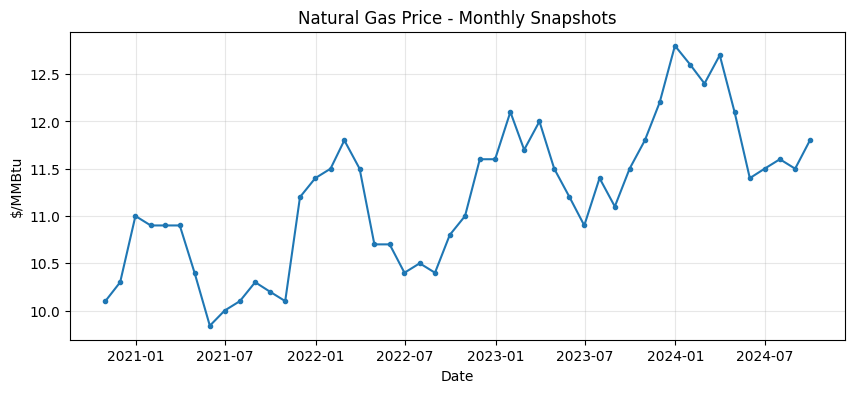

In [11]:
plt.plot(df['Dates'], df['Prices'], marker='o', ms=3)
plt.title('Natural Gas Price - Monthly Snapshots')
plt.ylabel('$/MMBtu'); plt.xlabel('Date')
plt.grid(alpha=0.3)
plt.show()

**Observation:** clear upward trend + a repeating wiggle each year (higher in winter months, dip mid-year) -> classic trend + seasonality pattern.

## 3. Feature engineering
- `t`: months elapsed since first observation (captures trend, linear here since range is short - always sanity check this assumption).
- `sin`, `cos` of month angle (period = 12 months): a smooth, 2-parameter way to encode "which month" instead of 11 dummies. Any point in the annual cycle is a combination of these two waves.

In [12]:
df['t'] = (df['Dates'].dt.year - df['Dates'].dt.year.min()) * 12 + (df['Dates'].dt.month - df['Dates'].dt.month.min())
angle = 2 * np.pi * df['Dates'].dt.month / 12
df['sin_m'] = np.sin(angle)
df['cos_m'] = np.cos(angle)
df[['Dates', 't', 'sin_m', 'cos_m']].head()

,Dates,t,sin_m,cos_m
0,2020-10-31,9,-8.660254e-01,0.500000
1,2020-11-30,10,-5.000000e-01,0.866025
2,2020-12-31,11,-2.449294e-16,1.000000
3,2021-01-31,12,5.000000e-01,0.866025
4,2021-02-28,13,8.660254e-01,0.500000


## 4. Fit OLS regression
Using `statsmodels` (not sklearn) because we want inferential statistics: coefficient p-values, confidence intervals, R² - this is the "statistical rigor" check, not just a fitted line.

In [13]:
X = sm.add_constant(df[['t', 'sin_m', 'cos_m']])
y = df['Prices']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     192.0
Date:                Sun, 26 Jul 2026   Prob (F-statistic):           2.74e-25
Time:                        08:46:48   Log-Likelihood:                 9.1988
No. Observations:                  48   AIC:                            -10.40
Df Residuals:                      44   BIC:                            -2.913
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.7243      0.078    124.497      0.0

**Reading the summary:**
- `R-squared` close to 1 -> trend + seasonality explain most of the variance.
- `P>|t|` for each term < 0.05 -> that term is statistically significant (not noise).
- Coefficient sign on `t` -> confirms upward trend; sizes of `sin_m`/`cos_m` -> seasonal swing amplitude.

## 5. Residual diagnostics
Before trusting extrapolation, residuals should look like white noise: no pattern left behind, no autocorrelation, roughly normal.

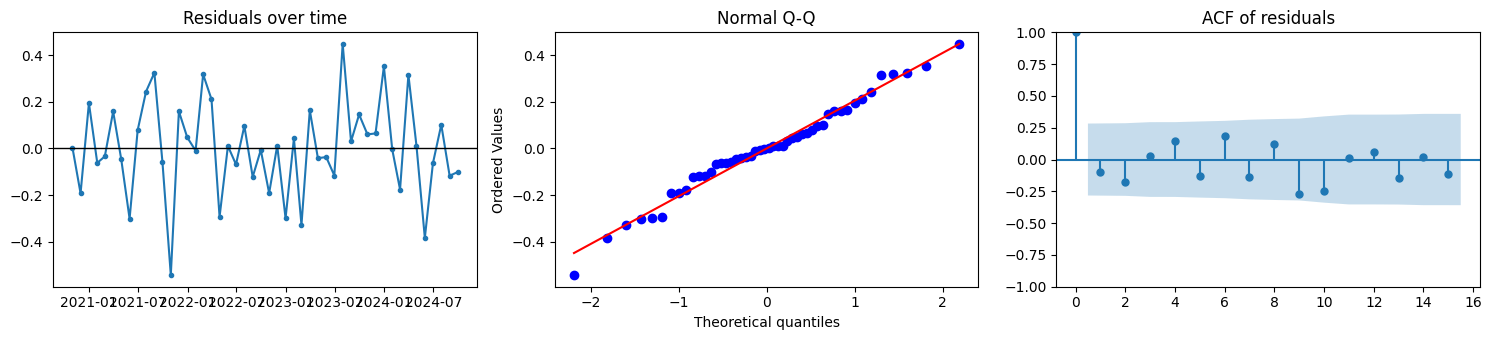

Durbin-Watson: 2.19  (~2 = no autocorrelation)


In [ ]:
resid = model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].plot(df['Dates'], resid, marker='o', ms=3)
axes[0].axhline(0, color='k', lw=1)
axes[0].set_title('Residuals over time')

stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q')

plot_acf(resid, ax=axes[2], lags=15)
axes[2].set_title('ACF of residuals')
plt.tight_layout(); plt.show()

print(f'Durbin-Watson: {durbin_watson(resid):.2f}  (~2 = no autocorrelation)')

**Checks:**
- DW close to 2 -> residuals not autocorrelated (model captured the seasonal cycle, didn't leave a leftover pattern).
- Q-Q plot roughly on the line -> residuals ~ normal -> OLS confidence intervals are trustworthy.
- If these actually had failed (e.g., DW << 2), we would suspect an unmodeled cycle or that the linear trend assumption breaks down over a longer horizon.

## 5b. Walk-forward validation
A single random train/test split is the wrong mental model when the goal is
*forecasting forward in time*. Instead: refit on an expanding window (only past data),
predict the next unseen month, repeat. This checks real forecasting accuracy, not just
in-sample fit.

In [14]:
errors = []
for cutoff in range(24, len(df) - 1):  # need enough history before first refit
    train = df.iloc[:cutoff]
    X_train = sm.add_constant(train[['t', 'sin_m', 'cos_m']])
    m = sm.OLS(train['Prices'], X_train).fit()

    next_row = df.iloc[[cutoff]]
    X_next = sm.add_constant(next_row[['t', 'sin_m', 'cos_m']], has_constant='add')
    pred = m.predict(X_next).iloc[0]
    errors.append(pred - next_row['Prices'].iloc[0])

errors = np.array(errors)
print(f'Walk-forward RMSE: {np.sqrt(np.mean(errors**2)):.3f}')
print(f'Walk-forward mean error (bias check): {errors.mean():.3f}')

Walk-forward RMSE: 0.222
Walk-forward mean error (bias check): -0.010


## 6. Price estimation function
Converts any date -> `(t, sin_m, cos_m)` -> predicted price + 95% prediction interval.
Works for:
- **Interpolation**: any day within Oct 2020 - Sep 2024 (not just month-end).
- **Extrapolation**: up to 1 year past Sep 2024 (`t` simply keeps increasing).

In [15]:
t0 = df['Dates'].min()
max_extrapolation_date = df['Dates'].max() + pd.DateOffset(years=1)

def estimate_price(date_str, ci=True):
    """Return price estimate for any date (string 'YYYY-MM-DD' or datetime).
    Raises if the date is more than 1 year past the last data point (extrapolation limit)."""
    date = pd.to_datetime(date_str)
    if date > max_extrapolation_date:
        raise ValueError(f'Date exceeds 1-year extrapolation limit ({max_extrapolation_date.date()})')

    # fractional month index relative to t0, continuous (not just month-end snapshots)
    t = (date.year - t0.year) * 12 + (date.month - t0.month) + (date.day - t0.day) / 30.44
    angle = 2 * np.pi * date.month / 12
    x_new = pd.DataFrame([[1, t, np.sin(angle), np.cos(angle)]], columns=['const', 't', 'sin_m', 'cos_m'])

    pred = model.get_prediction(x_new)
    point = pred.predicted_mean[0]
    if not ci:
        return point
    lo, hi = pred.conf_int(alpha=0.05)[0]
    return point, (lo, hi)

# quick tests
print('Historical (2022-06-15):', estimate_price('2022-06-15'))
print('At last data point (2024-09-30):', estimate_price('2024-09-30'))
print('Extrapolated (2025-06-30):', estimate_price('2025-06-30'))

Historical (2022-06-15): (np.float64(10.034123959171307), (np.float64(9.905047141373434), np.float64(10.16320077696918)))
At last data point (2024-09-30): (np.float64(11.489288664631724), (np.float64(11.368150634495256), np.float64(11.610426694768192)))
Extrapolated (2025-06-30): (np.float64(11.699076504551456), (np.float64(11.561850583491298), np.float64(11.836302425611615)))


**Interpolation vs. extrapolation uncertainty:** these are not the same thing. Inside the
data, the interval reflects sampling noise only. Beyond it, we're also trusting the trend
to keep holding - so the interval should visibly widen the further out we go. Confirm that
below rather than assuming it.

In [16]:
for months_ahead in [1, 3, 6, 9, 12]:
    d = df['Dates'].max() + pd.DateOffset(months=months_ahead)
    point, (lo, hi) = estimate_price(d)
    print(f'{months_ahead:>2} months beyond history -> price={point:.2f}, interval width={hi - lo:.3f}')

 1 months beyond history -> price=11.87, interval width=0.257
 3 months beyond history -> price=12.58, interval width=0.283
 6 months beyond history -> price=12.52, interval width=0.285
 9 months beyond history -> price=11.70, interval width=0.274
12 months beyond history -> price=12.04, interval width=0.310


## 7. Visualize full picture: fit + extrapolation
Plot actual data, fitted curve over history, and extrapolated curve with 95% CI band.

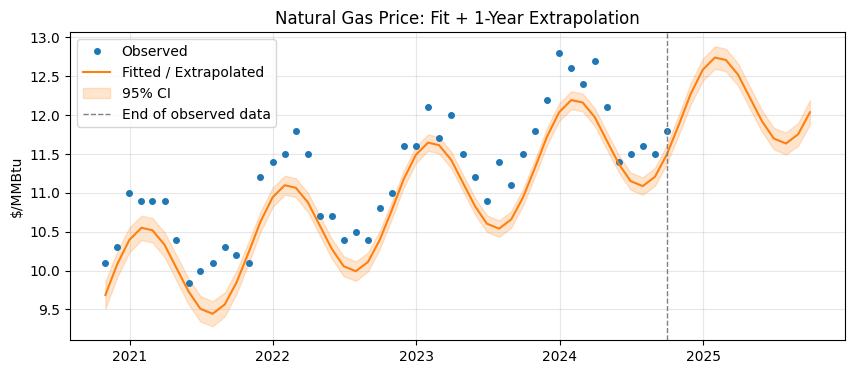

In [17]:
future_dates = pd.date_range(df['Dates'].max() + pd.DateOffset(months=1), periods=12, freq='ME')
all_dates = pd.concat([df['Dates'], pd.Series(future_dates)]).reset_index(drop=True)

preds = [estimate_price(d) for d in all_dates]
means = [p[0] for p in preds]
los = [p[1][0] for p in preds]
his = [p[1][1] for p in preds]

plt.plot(df['Dates'], df['Prices'], 'o', ms=4, label='Observed')
plt.plot(all_dates, means, '-', color='C1', label='Fitted / Extrapolated')
plt.fill_between(all_dates, los, his, color='C1', alpha=0.2, label='95% CI')
plt.axvline(df['Dates'].max(), color='gray', ls='--', lw=1, label='End of observed data')
plt.legend(); plt.grid(alpha=0.3)
plt.title('Natural Gas Price: Fit + 1-Year Extrapolation')
plt.ylabel('$/MMBtu')
plt.show()

**Scope note:** regime-switching / structural-break models were considered and deliberately
not fit here - with only 48 monthly points, there isn't enough data to reliably tell a real
structural break from ordinary noise. That's a flagged limitation of the extrapolation, not
something worth modeling at this sample size.

## Summary
- Trend + cyclical (sin/cos) OLS model fits the data well (check R² printed above) and residuals pass basic white-noise checks (DW ≈ 2, Q-Q roughly linear).
- `estimate_price(date)` gives a point estimate **and** a 95% confidence interval, works for any date within history or up to 1 year beyond it.
- Caveat: linear trend extrapolation assumes no structural change in gas market drivers (supply shocks, regulation) - fine for this exercise, but would flag this assumption in a real report to Alex.